In [1]:
# @title Running in Colab

from IPython.display import HTML, Javascript, display

display(
    HTML(
        """<a href="https://colab.research.google.com/github/evan-lloyd/mechinterp-experiments/blob/main/tiny_stories_sae/feature_interaction_demo.ipynb" target="_blank" id="colab-button">
            Run this notebook in Google Colab
        </a>"""
    )
)
display(
    Javascript("""
        setTimeout(() => {
            if(typeof google.colab != "undefined") {
                document.querySelector("#colab-button").remove()
            }
        }, 0);
        """)
)

<IPython.core.display.Javascript object>

# Initialize notebook environment

In [2]:
import os

# If we're running in Colab, we need to clone the non-notebook source from git.
if os.getenv("COLAB_RELEASE_TAG") and not os.path.isdir(
    "/content/mechinterp-experiments"
):
    ip = get_ipython()  #  pyright: ignore[reportUndefinedVariable]
    ip.run_cell_magic(
        "bash",
        "",
        """
    git clone --filter=blob:none --no-checkout https://github.com/evan-lloyd/mechinterp-experiments.git
    cd mechinterp-experiments
    git sparse-checkout init --no-cone
    echo "/tiny_stories_sae" > .git/info/sparse-checkout
    git checkout
  """,
    )
    ip.run_line_magic("cd", "mechinterp-experiments/tiny_stories_sae")
else:
    print("Already cloned source, or not running in Colab.")

# Nice for dev, but not needed for Colab.
try:
    # This uses a library called jurigged to hot-reload code when it is changed.
    # For reasons I've never been able to figure out, the IPython %autoreload magic
    # completely fails to work with the kind of structure I use in this notebook.
    import tiny_stories_sae._autoreload
except Exception:
    pass

Already cloned source, or not running in Colab.


In [3]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 16
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 8
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 8

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M")
training_dataset = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
validation_dataset = load_dataset(
    "roneneldan/TinyStories", split="validation", streaming=True
)
model = AutoModelForCausalLM.from_pretrained("roneneldan/TinyStories-33M").to(
    TRAINING_DEVICE
)

print(model)

GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(2048, 768)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-3): 4 x GPTNeoBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=False)
            (q_proj): Linear(in_features=768, out_features=768, bias=False)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (c_proj): Linear(in_feat

In [4]:
from math import sqrt

# Caches model activations to these directories; modify if necessary, or set to None to disable.
# These take up ~16GB and ~1.5GB respectively, but will save a fair bit of time when running
# the notebook, since they can be re-used across all methods we're comparing.
# Skip caching if CUDA is available, as at least on the cloud hardware I was using it was actually
# faster to just re-run the model than to load from disk! (Possibly my caching implementation is just bad.)
TRAINING_CACHE_DIR = None if torch.cuda.is_available() else ".training_cache"
VALIDATION_CACHE_DIR = None if torch.cuda.is_available() else ".validation_cache"
NUM_TRAINING_TOKENS = int(1e7) if torch.cuda.is_available() else int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e6) if torch.cuda.is_available() else int(1e5)
D_MODEL = model.config.hidden_size
D_SAE = D_MODEL * 8
# Match parameter count between interaction/no-interaction SAEs. Interaction adds
# D_SAE * D_SAE parameters to base SAE, which has 2 * D_SAE * D_MODEL + D_SAE + D_MODEL.
# By quadratic formula:
BASE_SAE_PARAMETERS = 2 * D_SAE * D_MODEL + D_SAE + D_MODEL
D_SAE_INTERACTION = int(
    (
        sqrt(((2 * D_MODEL + 1) ** 2 + 4 * (BASE_SAE_PARAMETERS - D_MODEL)))
        - (2 * D_MODEL + 1)
    )
    / 2
)
INTERACTION_SAE_PARAMETERS = (
    D_SAE_INTERACTION**2 + 2 * D_SAE_INTERACTION * D_MODEL + D_SAE_INTERACTION + D_MODEL
)
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

print(f"Parameter count (base): {BASE_SAE_PARAMETERS}")
print(f"Parameter count (interaction): {INTERACTION_SAE_PARAMETERS}")
print(f"d_sae/d_model (base): {D_SAE / D_MODEL}")
print(f"d_sae/d_model (interaction): {D_SAE_INTERACTION / D_MODEL}")

Parameter count (base): 9444096
Parameter count (interaction): 9443232
d_sae/d_model (base): 8.0
d_sae/d_model (interaction): 3.1236979166666665


# Train SAEs

In [5]:
from itertools import product

import numpy as np

from tiny_stories_sae.sae import (
    SAE,
    DecoderConfig,
    EncoderConfig,
    InteractionEncoderConfig,
    SAEConfig,
    TopKActivationFunctionConfig,
)
from tiny_stories_sae.training import TrainingConfig, TrainingMethod, fine_tune, train
from tiny_stories_sae.validation import run_validations


def SAE_SPECS():
    return product(TrainingMethod, (False, True))


empty_saes = {
    (method, use_interaction): {
        layer: SAE(
            SAEConfig(
                d_model=D_MODEL,
                d_sae=D_SAE_INTERACTION if use_interaction else D_SAE,
                device=TRAINING_DEVICE,
                encoder=EncoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                    activation_function=TopKActivationFunctionConfig(k=TOPK),
                )
                if not use_interaction
                else InteractionEncoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE_INTERACTION,
                    device=TRAINING_DEVICE,
                    activation_function=TopKActivationFunctionConfig(k=TOPK),
                    n_interaction_iterations=1,
                ),
                decoder=DecoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE_INTERACTION if use_interaction else D_SAE,
                    device=TRAINING_DEVICE,
                ),
            )
        )
        for layer in range(model.config.num_layers)
    }
    for method, use_interaction in SAE_SPECS()
}

# Double-check the parameter count math
for spec in SAE_SPECS():
    for sae in empty_saes[spec].values():
        assert (p_actual := sum(p.numel() for p in sae.parameters())) == (
            INTERACTION_SAE_PARAMETERS if spec[1] else BASE_SAE_PARAMETERS
        ), (
            f"Expected {INTERACTION_SAE_PARAMETERS} parameters for {spec}, got {p_actual}"
        )


def linear_decay_during_finetune(frac_trained: float):
    if frac_trained < (1 - FINETUNE_FRACTION):
        return 1.0
    return 1.0 - (frac_trained - (1 - FINETUNE_FRACTION)) / FINETUNE_FRACTION


training_config = {
    (method, use_interaction): TrainingConfig(
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        training_batch_size=TRAINING_BATCH_SIZE,
        num_train_tokens=NUM_TRAINING_TOKENS,
        eval_interval=EVAL_INTERVAL,
        train_layers=list(range(model.config.num_layers)),
        lr=1e-3,
        interaction_lr=1e-3,
        lr_schedule=linear_decay_during_finetune,  # per Karvonen (2025)
        downstream_reconstruction_weight=1.0,
        reconstruction_weight=1.0,
        balance_reconstruction_losses=True,
        method=method,
        finetune_fraction=FINETUNE_FRACTION
        if method in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned)
        else None,
    )
    for method, use_interaction in SAE_SPECS()
}

training_results = {}
validation_results = {}

In [6]:
import os

from tiny_stories_sae.activation_cache import build_cache

if TRAINING_CACHE_DIR and (
    not os.path.exists(TRAINING_CACHE_DIR) or not os.listdir(TRAINING_CACHE_DIR)
):
    build_cache(
        TRAINING_CACHE_DIR,
        model,
        tokenizer,
        training_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_TRAINING_TOKENS,
    )

if VALIDATION_CACHE_DIR and (
    not os.path.exists(VALIDATION_CACHE_DIR) or not os.listdir(VALIDATION_CACHE_DIR)
):
    build_cache(
        VALIDATION_CACHE_DIR,
        model,
        tokenizer,
        validation_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_VALIDATION_TOKENS,
    )

In [7]:
for spec in SAE_SPECS():
    # We finetune these from checkpoints of other methods
    if spec[0] in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned):
        continue
    print(f"Training {spec[0].value}, use_interaction={spec[1]}")
    training_results[spec] = train(
        model,
        tokenizer,
        empty_saes[spec],
        training_dataset,
        training_config[spec],
        cache_dir=TRAINING_CACHE_DIR,
        checkpoints_at=[int((1.0 - FINETUNE_FRACTION) * NUM_TRAINING_TOKENS)]
        if spec[0] in (TrainingMethod.standard, TrainingMethod.next_layer)
        else None,
    )
    validation_results[spec] = run_validations(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        cache_dir=VALIDATION_CACHE_DIR,
    )
    print(
        f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })"
    )
    print(
        f"geom mean kl={ {k: np.exp(np.mean(np.log(np.clip(v.kl, min=1e-9)))).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })"
    )

Training Standard, use_interaction=False


Layer 3

  0%|          | 0/10000000 [00:00<?, ?it/s]

Layer 2

  0%|          | 0/10000000 [00:00<?, ?it/s]

...

  0%|          | 0/10000000 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/10000000 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

mean rre={0: 0.4399794936180115, 1: 0.46748754382133484, 2: 0.5414445400238037, 3: 0.6673446297645569})
geom mean kl={4: 0.11052822321653366})


In [9]:
for spec in SAE_SPECS():
    if spec[0] not in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned):
        continue
    print(f"Training {spec[0].value}, use_interaction={spec[1]}")
    training_results[spec] = fine_tune(
        model,
        tokenizer,
        training_results[
            (
                TrainingMethod.standard
                if spec[0] == TrainingMethod.finetuned
                else TrainingMethod.next_layer,
                spec[1],
            )
        ],
        0,
        training_dataset,
        training_config[spec],
        cache_dir=TRAINING_CACHE_DIR,
    )
    validation_results[spec] = run_validations(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        cache_dir=VALIDATION_CACHE_DIR,
    )
    print(
        f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })"
    )
    print(
        f"geom mean kl={ {k: np.exp(np.mean(np.log(np.clip(v.kl, min=1e-9)))).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })"
    )

Training KL Fine-tuning, use_interaction=False


Layer 3

  0%|          | 0/994735 [00:00<?, ?it/s]

Layer 2

  0%|          | 0/994735 [00:00<?, ?it/s]

...

  0%|          | 0/994735 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/994735 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

mean rre={0: 0.21809351444244385, 1: 0.3025569021701813, 2: 0.4162556529045105, 3: 0.6699962019920349})
geom mean kl={4: 0.10103172063827515})


In [10]:
# Print KL statistics as an HTML table
from tiny_stories_sae.ops import display_sortable_html_table

headers = [
    "Layer",
    "Method",
    "Interaction",
    "Geometric Mean KL",
    "GSD Lower",
    "GSD Upper",
]
rows = []

for layer in [model.config.num_layers]:
    for spec, results in validation_results.items():
        if layer not in results.layer_results:
            continue

        interaction_label = "Yes" if spec[1] else "No"
        kl_values = results.layer_results[layer].kl
        kl_positive = np.clip(kl_values, min=1e-9)
        log_kl = np.log(kl_positive)
        log_mean = np.mean(log_kl)
        log_std = np.std(log_kl)
        gm = np.exp(log_mean)
        gsd = np.exp(log_std)
        gsd_lower = gm - gm / gsd
        gsd_upper = gm * gsd - gm

        rows.append(
            [
                layer,
                spec[0].value,
                interaction_label,
                f"{gm:.6f}",
                f"{gsd_lower:.6f}",
                f"{gsd_upper:.6f}",
            ]
        )

display_sortable_html_table(headers, rows)

Layer ⇅,Method ⇅,Interaction ⇅,Geometric Mean KL ⇅,GSD Lower ⇅,GSD Upper ⇅
4,Standard,No,0.146665,0.138331,2.434363
4,Standard,Yes,0.171427,0.160352,2.482066
4,Next Layer,No,0.120880,0.112707,1.666933
4,Next Layer,Yes,0.114441,0.106572,1.549977
4,End-to-end,No,0.125781,0.116274,1.538333
4,End-to-end,Yes,0.157535,0.145351,1.879431
4,End-to-end Full Replacement,No,0.107828,0.102323,2.004288
4,End-to-end Full Replacement,Yes,0.110528,0.104908,2.062972
4,KL Fine-tuning,No,0.155080,0.141501,1.616035
4,KL Fine-tuning,Yes,0.159202,0.145750,1.724892


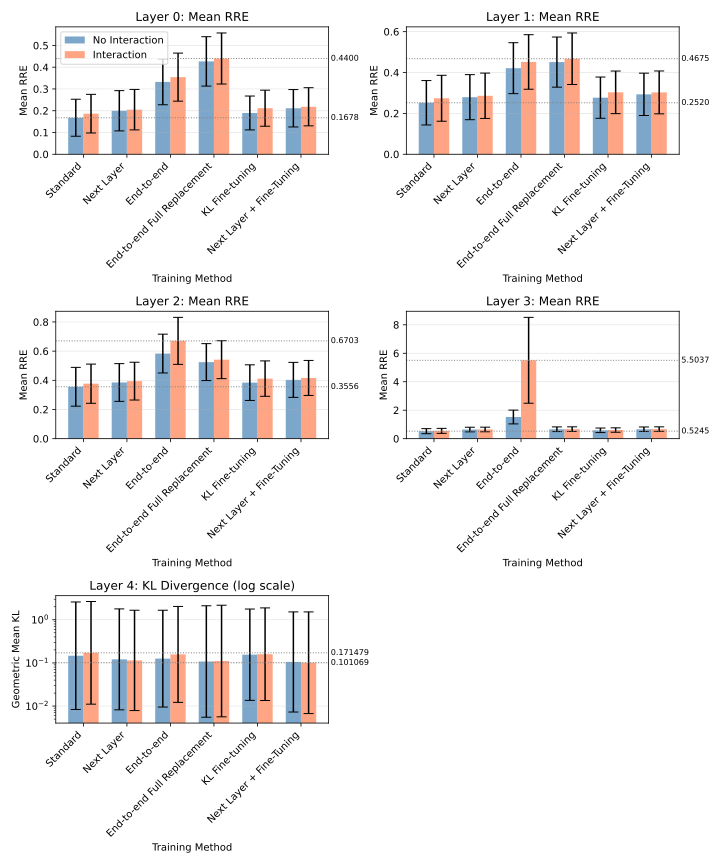

In [11]:
import matplotlib.pyplot as plt
import numpy as np

from tiny_stories_sae.ops import current_plot_to_svg

num_plots = model.config.num_layers + 1
num_cols = 2
num_rows = (num_plots + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten()

plot_idx = 0

# Group specs by method
methods = []
seen_methods = set()
for spec in validation_results:
    if spec[0] not in seen_methods:
        methods.append(spec[0])
        seen_methods.add(spec[0])

method_labels = [m.value for m in methods]
x = np.arange(len(methods))
bar_width = 0.35

colors = {'no_interaction': 'steelblue', 'interaction': 'coral'}

# Plot RRE bar charts for each layer
# First pass: compute global max for RRE across all layers
rre_max = 0
for layer in range(model.config.num_layers):
    for method in methods:
        for use_interaction in [False, True]:
            spec = (method, use_interaction)
            if spec in validation_results and layer in validation_results[spec].layer_results:
                rre_values = validation_results[spec].layer_results[layer].rre
                if rre_values is not None and len(rre_values) > 0:
                    rre_max = max(rre_max, np.mean(rre_values) + np.std(rre_values))

for layer in range(model.config.num_layers):
    ax = axes[plot_idx]
    means_no_int = []
    stds_no_int = []
    means_int = []
    stds_int = []
    
    for method in methods:
        # No interaction
        spec_no_int = (method, False)
        if spec_no_int in validation_results and layer in validation_results[spec_no_int].layer_results:
            rre_values = validation_results[spec_no_int].layer_results[layer].rre
            if rre_values is not None and len(rre_values) > 0:
                means_no_int.append(np.mean(rre_values))
                stds_no_int.append(np.std(rre_values))
            else:
                means_no_int.append(0)
                stds_no_int.append(0)
        else:
            means_no_int.append(0)
            stds_no_int.append(0)
        
        # With interaction
        spec_int = (method, True)
        if spec_int in validation_results and layer in validation_results[spec_int].layer_results:
            rre_values = validation_results[spec_int].layer_results[layer].rre
            if rre_values is not None and len(rre_values) > 0:
                means_int.append(np.mean(rre_values))
                stds_int.append(np.std(rre_values))
            else:
                means_int.append(0)
                stds_int.append(0)
        else:
            means_int.append(0)
            stds_int.append(0)
    
    ax.bar(x - bar_width/2, means_no_int, bar_width, yerr=stds_no_int, capsize=5, alpha=0.7, 
           color=colors['no_interaction'], label='No Interaction')
    ax.bar(x + bar_width/2, means_int, bar_width, yerr=stds_int, capsize=5, alpha=0.7,
           color=colors['interaction'], label='Interaction')
    ax.set_xlabel("Training Method")
    ax.set_ylabel("Mean RRE")
    ax.set_title(f"Layer {layer}: Mean RRE")
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, rotation=45, ha='right')
    # ax.set_ylim(0, rre_max * 1.1)
    ax.grid(True, alpha=0.3, axis='y')
    if plot_idx == 0:
        ax.legend()
    
    # Add horizontal dotted lines at highest and lowest values
    all_means = means_no_int + means_int
    non_zero_means = [m for m in all_means if m > 0]
    if non_zero_means:
        max_val = max(non_zero_means)
        min_val = min(non_zero_means)
        ax.axhline(y=max_val, color='gray', linestyle=':', linewidth=1)
        ax.axhline(y=min_val, color='gray', linestyle=':', linewidth=1)
        ax.text(ax.get_xlim()[1] + 0.05, max_val, f'{max_val:.4f}', va='center', fontsize=8)
        ax.text(ax.get_xlim()[1] + 0.05, min_val, f'{min_val:.4f}', va='center', fontsize=8)
    
    plot_idx += 1

# Plot KL bar charts in log-space for each layer that has it
for layer in [model.config.num_layers]:
    ax = axes[plot_idx]
    gmeans_no_int = []
    gstd_lower_no_int = []
    gstd_upper_no_int = []
    gmeans_int = []
    gstd_lower_int = []
    gstd_upper_int = []
    
    for method in methods:
        # No interaction
        spec_no_int = (method, False)
        if spec_no_int in validation_results and layer in validation_results[spec_no_int].layer_results:
            kl_values = validation_results[spec_no_int].layer_results[layer].kl
            if kl_values is not None and len(kl_values) > 0:
                kl_positive = kl_values[kl_values > 0]
                if len(kl_positive) > 0:
                    log_kl = np.log(kl_positive)
                    log_mean = np.mean(log_kl)
                    log_std = np.std(log_kl)
                    gm = np.exp(log_mean)
                    gmeans_no_int.append(gm)
                    gsd = np.exp(log_std)
                    gstd_lower_no_int.append(gm - gm / gsd)
                    gstd_upper_no_int.append(gm * gsd - gm)
                else:
                    gmeans_no_int.append(0)
                    gstd_lower_no_int.append(0)
                    gstd_upper_no_int.append(0)
            else:
                gmeans_no_int.append(0)
                gstd_lower_no_int.append(0)
                gstd_upper_no_int.append(0)
        else:
            gmeans_no_int.append(0)
            gstd_lower_no_int.append(0)
            gstd_upper_no_int.append(0)
        
        # With interaction
        spec_int = (method, True)
        if spec_int in validation_results and layer in validation_results[spec_int].layer_results:
            kl_values = validation_results[spec_int].layer_results[layer].kl
            if kl_values is not None and len(kl_values) > 0:
                kl_positive = kl_values[kl_values > 0]
                if len(kl_positive) > 0:
                    log_kl = np.log(kl_positive)
                    log_mean = np.mean(log_kl)
                    log_std = np.std(log_kl)
                    gm = np.exp(log_mean)
                    gmeans_int.append(gm)
                    gsd = np.exp(log_std)
                    gstd_lower_int.append(gm - gm / gsd)
                    gstd_upper_int.append(gm * gsd - gm)
                else:
                    gmeans_int.append(0)
                    gstd_lower_int.append(0)
                    gstd_upper_int.append(0)
            else:
                gmeans_int.append(0)
                gstd_lower_int.append(0)
                gstd_upper_int.append(0)
        else:
            gmeans_int.append(0)
            gstd_lower_int.append(0)
            gstd_upper_int.append(0)
    
    ax.bar(x - bar_width/2, gmeans_no_int, bar_width, yerr=[gstd_lower_no_int, gstd_upper_no_int], 
           capsize=5, alpha=0.7, color=colors['no_interaction'], label='No Interaction')
    ax.bar(x + bar_width/2, gmeans_int, bar_width, yerr=[gstd_lower_int, gstd_upper_int],
           capsize=5, alpha=0.7, color=colors['interaction'], label='Interaction')
    ax.set_yscale('log')
    ax.set_xlabel("Training Method")
    ax.set_ylabel("Geometric Mean KL")
    ax.set_title(f"Layer {layer}: KL Divergence (log scale)")
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    # ax.legend()
    
    # Add horizontal dotted lines at highest and lowest values
    all_gmeans = gmeans_no_int + gmeans_int
    non_zero_gmeans = [m for m in all_gmeans if m > 0]
    if non_zero_gmeans:
        max_val = max(non_zero_gmeans)
        min_val = min(non_zero_gmeans)
        ax.axhline(y=max_val, color='gray', linestyle=':', linewidth=1)
        ax.axhline(y=min_val, color='gray', linestyle=':', linewidth=1)
        ax.text(ax.get_xlim()[1] + 0.05, max_val, f'{max_val:.6f}', va='center', fontsize=8)
        ax.text(ax.get_xlim()[1] + 0.05, min_val, f'{min_val:.6f}', va='center', fontsize=8)
    
    plot_idx += 1

# Hide any unused axes
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
current_plot_to_svg()

In [12]:
# Print RRE statistics as an HTML table
from tiny_stories_sae.ops import display_sortable_html_table

headers = ["Layer", "Method", "Interaction", "Mean RRE", "Std RRE"]
rows = []

for layer in range(model.config.num_layers):
    for spec, results in validation_results.items():
        if layer not in results.layer_results:
            continue
        interaction_label = "Yes" if spec[1] else "No"

        rre_values = results.layer_results[layer].rre
        mean_rre = np.mean(rre_values)
        std_rre = np.std(rre_values)

        rows.append(
            [
                layer,
                spec[0].value,
                interaction_label,
                f"{mean_rre:.6f}",
                f"{std_rre:.6f}",
            ]
        )

display_sortable_html_table(headers, rows)

Layer ⇅,Method ⇅,Interaction ⇅,Mean RRE ⇅,Std RRE ⇅
0,Standard,No,0.167772,0.084895
0,Standard,Yes,0.186527,0.088758
0,Next Layer,No,0.199696,0.092555
0,Next Layer,Yes,0.204967,0.092975
0,End-to-end,No,0.332220,0.104871
0,End-to-end,Yes,0.354458,0.110487
0,End-to-end Full Replacement,No,0.426732,0.113564
0,End-to-end Full Replacement,Yes,0.439979,0.117446
0,KL Fine-tuning,No,0.189678,0.077840
0,KL Fine-tuning,Yes,0.211515,0.082867


In [14]:
from tiny_stories_sae.validation import generate_with_replacement
from IPython.display import HTML

# Generate completions with and without SAE replacement
prompt = "Once upon a time"
sample_generations = {}

# Generate without replacement (baseline)
print("Generating baseline completion...")
baseline_tokens = generate_with_replacement(
    model, tokenizer, prompt, saes={}, do_sample=False, stream=False
)
sample_generations["Baseline"] = tokenizer.decode(
    baseline_tokens[0], skip_special_tokens=True
)

# Generate with each SAE method
for spec, results in training_results.items():
    print(f"Generating completion with {spec[0].value}...")
    method_tokens = generate_with_replacement(
        model,
        tokenizer,
        prompt,
        saes=results.final_saes,
        do_sample=False,
        stream=False,
    )
    sample_generations[spec[0].value] = tokenizer.decode(
        method_tokens[0], skip_special_tokens=True
    )

# Display results in HTML table
html_table = """
<table border="1" style="border-collapse: collapse; width: 100%;">
<tr style="background-color: #f2f2f2;">
<th style="padding: 10px; text-align: left;">Method</th>
<th style="padding: 10px; text-align: left;">Generated Text</th>
</tr>
"""

for method_name, text in sample_generations.items():
    html_table += f"""
<tr>
<td style="padding: 10px; vertical-align: top; font-weight: bold;">{method_name}</td>
<td style="padding: 10px; font-family: monospace; white-space: pre-wrap;">{text}</td>
</tr>
"""

html_table += "</table>"

display(HTML(html_table))


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating baseline completion...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating completion with Standard...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating completion with Next Layer + Fine-Tuning...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating completion with Next Layer + Fine-Tuning...


Method,Generated Text
Baseline,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big, red apple on the ground. She picked it up and took a bite. It was so juicy and delicious! Suddenly, she heard a loud noise. It was a big, scary dog! Lily was scared and didn't know what to do. But then, she remembered the apple she had picked earlier. She took a bite and it was even more delicious than before! Lily learned that sometimes things that look scary can be delicious. She also learned that it's important to be brave and not give up. From that day on, Lily always carried an apple with her, just in case she needed to face her fears."
Standard,"Once upon a time, there was a little girl named Lily. She loved to play outside in the park. One day, she saw a big, red ball. She wanted to play with it, but it was too big for her to reach it. Lily's mommy said, ""Let's go find a stick to help you reach it."" So, they went to the park. Lily found a stick that was very useful. She held the stick tight and tried to reach it. Suddenly, Lily saw a big, red ball. She picked it up and said, ""Mommy, can I play with this ball?"" Her mommy said, ""Yes, but be careful and don't throw it too far."" Lily was happy and played with the ball until it was time to go home."
Next Layer,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big, red ball in the park. She wanted to play with it, but it was too high for her. Lily's mommy told her that if she wanted to play with the ball, she could use the ball to catch it. Lily was so happy! She started to play with the ball and had so much fun. After a while, Lily's mommy came to the park to play with her. She saw that Lily had a big, red ball and wanted to play with it too. She threw the ball to Lily and they played together until it was time to go home. Lily was so happy to have a fun day with her ball. She knew that she could use the ball again tomorrow. She couldn't wait to play with it again."
End-to-end,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big, red ball in the distance. She wanted to play with it, but it was too far away. Lily asked her mommy, ""Can I play with the ball?"" Her mommy replied, ""No, it's too far away."" Lily was sad, but then she had an idea. She went to the store and bought a new ball. She went back to the ball and kicked it around. It was so much fun! After playing with the ball, Lily's mommy said, ""Lily, you are such a good player. You can't have the ball by yourself."" Lily smiled and said, ""Thank you, Mommy! I will never forget this fun day."" The moral of the story is that sometimes we can't have everything we want, but we can still have fun with our friends."
End-to-end Full Replacement,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big, scary dog running towards her. She was scared and didn't know what to do. Lily's mom saw her and said, ""Don't worry, Lily. The dog is just a little scared. It's just a dog. It's just a dog."" Lily felt better and went back outside to play. She saw the dog again and the dog came closer. The dog was wagging its tail and wagged its tail. Lily was happy to see the dog and the dog was happy to have a new friend. From that day on, Lily and the dog played together every day. They would run and jump and have fun. Lily was no longer scared of the big, scary dog anymore."
KL Fine-tuning,"Once upon a time, there was a little girl named Lily. She loved to play with her toys and her favorite was a big, red ball. One day, Lily's mommy asked her to help her bake the cake. Lily was excited to help and started to stir the batter. As they were baking the cake, Lily's mommy accidentally dropped the ball and it rolled out of the oven. Lily was sad because she couldn't play with her ball anymore

In [ ]:
from tiny_stories_sae.ops import save_training_result, ensure_directory

if SAVE_FINAL_RESULTS:
    ensure_directory(".checkpoints")
    ensure_directory(".checkpoints/feature_interaction_demo")
    for spec in training_results.keys():
        save_training_result(
            training_results[spec],
            f".checkpoints/feature_interaction_demo/{spec[0].name}{'_interaction' if spec[1] else ''}",
        )

In [ ]:
# from tiny_stories_sae.ops import load_training_result

# loaded_saes = {
#     k: v.change_configured_device(TRAINING_DEVICE)
#     for k, v in load_training_result(
#         ".checkpoints/feature_interaction_demo/e2e"
#     ).final_saes.items()
# }